# Públicos diferentes, notas diferentes

Primeira Entrega (E1) de Gestão Estratégica da Tecnologia da Informação (EPS7008, UFSC/EPS).

Grupo: **José Eduardo Pereira, Amaury Philippot e Lucas Christian Harmodio Fraile**.

Este caderno é o entregável da E1. Ele explica o projeto, as bases, o tratamento que virou o pacote de dados
e, no fim, a análise. Tudo que ele lê vem do pacote congelado `pacote-e1-2026-09-13` (tag `v0.1-e1-dados`);
o código que gerou o pacote, os relatórios de cada etapa e os cadernos anteriores estão no repositório
[quem-avalia-o-que](https://github.com/joseduardop/quem-avalia-o-que).

**Como rodar.** No Colab: a pasta compartilhada `eps7008-e1` precisa de um atalho no Meu Drive
(botão direito -> Organizar -> Adicionar atalho ao Drive), depois Runtime -> Run all. Local: clone do repo,
pacote descompactado em `datalake/pacote/` e o caderno aberto a partir de `notebooks/`.


## 1. o projeto

**Tese:** públicos de plataformas diferentes avaliam as mesmas obras de forma diferente. Quem dá 10 no IMDb
não é quem dá 5 estrelas no Letterboxd, e a diferença não é ruído: tem direção, tem década, tem país.

**Unidade de análise:** o título (filme). Cada filme aparece uma vez por plataforma, com a nota média e o
volume de votos que a plataforma acumulou pra ele.

**O que se mede:** a divergência entre plataformas na *posição* que o filme ocupa dentro da distribuição de
cada uma. Nunca média contra média, por três motivos que estão nos dados:

1. as escalas são diferentes (IMDb 1-10, TMDB 0-10, Letterboxd e MovieLens 0,5-5);
2. as distribuições são diferentes (a mediana de votos por filme é 16 mil no IMDb e 319 no Letterboxd);
3. a média muda com o recorte: no IMDb ela vai de 5,75 (filmes com 100-1.000 votos) a 6,99 (100 mil+)
   só mudando a faixa de volume.

Por isso toda comparação usa `nota_z` (z-score dentro da plataforma), `nota_pct` (percentil dentro da
plataforma) ou `gap_z` (diferença de z entre duas plataformas, calculada só sobre os filmes que as duas têm).

**As perguntas que guiam a análise** (cada uma já com o controle dentro):

- o gap entre IMDb e Letterboxd cresce com a década, dentro de quartil de visibilidade? em que sinal?
- qual par de plataformas mais discorda, e a discordância se concentra em década, país ou gênero?
- filmes de país único não-EUA têm gap diferente dos EUA na mesma década e quartil?
- a divergência de visibilidade (muitos votos no IMDb, poucos no Letterboxd) tem perfil?
- a nota de um filme deriva com a distância entre lançamento e avaliação?
- o gradiente de idade, que some no agregado, reaparece em algum gênero?

## 2. as bases

Cinco fontes, mais uma que só serve de ponte. Nenhum dado por título está no repositório: os termos de uso
não permitem redistribuir, então `datalake/` fica fora do git e o pacote circula na pasta do grupo.

| fonte | o que se usa | coleta | licença / termos |
|---|---|---|---|
| **IMDb non-commercial datasets** | `title.basics` (tipo, título, ano, duração, gêneros) e `title.ratings` (nota média, votos) | 13/09/2026 | uso pessoal e não comercial, sem redistribuição |
| **TMDB API** | por filme: `external_ids` (valida o `imdb_id`), nota, votos, países de produção, classificação indicativa | 13/09/2026, 17.858 requisições | termos da API; atribuição obrigatória |
| **MovieLens ml-32m** | `links.csv` (movieId -> imdbId, tmdbId) e `ratings.csv` (32 M notas com timestamp, 1995-2023) | gerado em 13/10/2023 | pesquisa, sem redistribuição; citar Harper & Konstan (2015) |
| **MovieLens ml-1m** | `ratings.dat`, `users.dat` (faixa etária, gênero, ocupação); janela 04/2000-02/2003 | 2003 | idem |
| **Letterboxd film ratings** (freeth, Kaggle) | `films.csv` (slug, nome, ano) e `ratings.csv` (18,2 M notas de 11.061 usuários) | dump de 10/10/2023 | CC0-1.0 |
| **Wikidata** | P6127 (slug do Letterboxd) -> P345 (IMDb) e P4947 (TMDB), 269.188 linhas | 13/09/2026 | CC0 |

O que cada uma é de verdade, porque isso muda a leitura:

- **IMDb e TMDB** são acumulados: todo mundo que já votou até a data da coleta. IMDb é a plataforma grande
  (mediana de 16 mil votos por filme do frame); TMDB é a mesma ideia com um público muito menor.
- **Letterboxd** não é a plataforma, é uma **amostra de 11.061 usuários pesados** (~1.640 notas cada) que
  alguém extraiu e publicou no Kaggle. As médias são desses usuários. E o dump é de outubro de 2023, então
  o frame para em 2023.
- **ml-32m** são os usuários do MovieLens de 1995 a 2023, cada nota com timestamp. É a única fonte em que dá
  pra ver a nota de um mesmo filme mudando com o tempo.
- **ml-1m** é uma janela de 2000-2003 com demografia do usuário (faixa etária e gênero). Cobre 2.717 títulos
  do frame (15%), os que estavam no MovieLens em 2000. Acumulado não se compara com janela: o acumulado
  contém a janela.
- **Wikidata** não entra na análise; é o que liga o slug do Letterboxd ao id do IMDb, porque o Letterboxd
  não publica id externo.


## 3. o tratamento

### 3.1 arquitetura

Arquitetura medalhão em arquivo, sem banco: cada camada é um diretório de parquet, e o DuckDB consulta os
arquivos direto.

```
landing   as fontes como baixadas (tsv, csv, json do crawl)
bronze    tipado e fiel à fonte, uma tabela por arquivo
silver    regra de negócio: frame, ponte de ids, fatos em formato longo
gold      agregados e normalizações pra análise
pacote    silver + gold + README, congelado e zipado
```

O pipeline é SQL, um script por etapa (`bronze.sql -> silver.sql -> processa_tmdb.py -> silver_tmdb.sql
-> silver_notas.sql -> gold.sql -> gold_tmdb.sql -> gold_notas.sql`), rodado por um runner de 40 linhas
que executa cada statement no DuckDB. O crawler, o parser do JSONL do TMDB e os checks de integridade são
Python. Tudo é idempotente e o
`etl/run.sh` reconstrói bronze, silver e gold em ~20 s; o crawl (15 min) roda uma vez e fica em landing.

### 3.2 o frame: 17.810 filmes

`titleType = movie`, 5.000+ votos no IMDb, ano de 1930 a 2023. O corte de 5.000 não é sobre o IMDb: abaixo
dele a cobertura do Letterboxd desaba (14% dos filmes com 100+ notas). O piso de 1930 é porque os anos 1920
ficam com 66 filmes, fino demais pra estrato próprio; o teto de 2023 é o dump do Letterboxd.

O corte seleciona coisas diferentes em cada década: nos anos 1930 sobra a elite (198 filmes), nos 2010 sobra
todo lançamento mediano (5.690). Por isso cada filme carrega `pct_votos_decada`, sua posição por votos dentro
da própria década (0 = menos votado, 1 = mais votado), e toda comparação entre décadas vai dentro de faixa
dessa posição. O quartil superior (`>= 0,75`) é o que chamamos de cânone da década.

### 3.3 identidade: quem é quem entre as fontes

- **Letterboxd -> IMDb pelo Wikidata** (P6127 -> P345). 99,6% do frame tem slug no Wikidata e 98,5% tem
  slug que existe no dump. Casamento por título e ano foi testado e descartado.
- **`tmdb_id`** vem do MovieLens e do Wikidata e é **validado contra `external_ids.imdb_id`** em todas as
  linhas: 99,97% do frame com registro confirmado. Nas 19 divergências entre as duas fontes, o Wikidata
  acertou 18 e o MovieLens zero (15 dos ids do MovieLens eram entradas que o TMDB já apagou).
- Duplicatas do Wikidata são produto cartesiano do SPARQL sobre propriedade multivalorada; a regra é uma
  linha por par (id, slug) e desempate por volume de notas. Dentro do frame isso toca 6 filmes.

### 3.4 país

`production_countries` do TMDB, 99,6% do frame. A ordem da lista nas coproduções não significa nada e
idioma não é nacionalidade, então **não existe país primário**: `pais_unico` é preenchido só quando o filme
tem um país (71% do frame), coprodução é categoria própria, e `tem_us` separa "GB sozinho" de "GB com os
EUA". Estratos limpos com 100+ filmes: US, IN, GB, JP, FR, TR, CA, KR, IT, DE, ES, AU.

### 3.5 notas

`fato_notas` é o formato longo: uma linha por (título, plataforma), com nota na escala da plataforma,
`escala_min`, `escala_max`, `n_votos` e `data_coleta`. Sem filtro de volume: um filme com 18 mil votos no
IMDb e 11 notas no Letterboxd está lá, e a assimetria é dado.

A normalização só existe no gold, porque muda com o recorte:

- `notas_normalizadas`: `fato_notas` com `n_votos >= 30`, mais `nota_z` e `nota_pct` dentro da plataforma;
- `divergencia_par`: por título e par de plataformas, com z recalculado **só sobre os títulos que o par tem
  em comum**, e `gap_z = z_b - z_a`. Em cada par `b` é a plataforma que vem depois em ordem alfabética,
  então em `imdb_letterboxd` o gap é `z_letterboxd - z_imdb`: **positivo = Letterboxd avalia o filme
  relativamente melhor**, negativo = IMDb.

Do ml-32m sai `deriva_ml32` (por título e ano de avaliação, desvio da nota do ano contra a média do próprio
filme) e do ml-1m sai `notas_por_faixa_etaria` (por título e faixa, desvio da faixa contra a média do filme
entre todos). Os dois medem dentro do filme, o que elimina a composição da cesta.

### 3.6 checks e pacote

26 checks de integridade rodam no fim do pipeline (chaves únicas, cobertura da ponte, escalas, z com média
zero por plataforma, contagens relativas ao frame). O pacote é gerado com `VERSAO.txt` (data, commit, fontes,
resultado dos checks) e congelado: IMDb, TMDB e Wikidata mudam todo dia, e baixar de novo muda o frame. Os
números deste caderno são os do pacote, não os de um download novo.

### 3.7 o que não fazer

As sete regras que separam resultado de artefato, e que a análise abaixo segue:

1. não comparar média com média entre plataformas;
2. lembrar que o Letterboxd é amostra de usuários pesados, não a plataforma;
3. não comparar acumulado com janela;
4. cobertura baixa do Letterboxd é canonicidade, não dado faltante;
5. comparação entre décadas só dentro de faixa de `pct_votos_decada`;
6. país é `pais_unico`, coprodução é categoria própria;
7. a demografia cobre 15% do frame, e isso se declara.


## 4. setup

No Colab monta o Drive e aponta `PACOTE` pra pasta descompactada; local, aponta pra `datalake/pacote/`.


In [1]:
import os
import sys

NO_COLAB = "google.colab" in sys.modules
if NO_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PACOTE = "/content/drive/MyDrive/eps7008-e1/pacote-e1-2026-09-13"
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb"], check=True)
else:
    PACOTE = "../datalake/pacote/pacote-e1-2026-09-13"

assert os.path.exists(f"{PACOTE}/VERSAO.txt"), "pacote não encontrado: ajuste PACOTE"
print(open(f"{PACOTE}/VERSAO.txt").read())

pacote: pacote-e1-2026-09-13
gerado em: 2026-09-13 16:19 -03
commit: d584668 (docs: readme do repo, fontes e reprodutibilidade do zero)
checks: 26/26 checks ok
fontes: imdb e tmdb coletados em 2026-09-13; letterboxd (kaggle/freeth) dump de 2023-10-10; ml-32m gerado em 2023-10-13; ml-1m janela 2000-2003



In [2]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

con = duckdb.connect()
for camada in ("silver", "gold"):
    for arquivo in sorted(os.listdir(f"{PACOTE}/{camada}")):
        nome = arquivo.removesuffix(".parquet")
        con.sql(f"create or replace view {nome} as select * from '{PACOTE}/{camada}/{arquivo}'")
con.sql("select view_name from duckdb_views() where not internal order by 1").df().view_name.tolist()

['arbitragem_tmdb',
 'classificacao_br',
 'classificacao_br_decada',
 'cobertura_canonicidade',
 'cobertura_decada_faixa',
 'cobertura_ponte',
 'cobertura_ponte_decada',
 'cobertura_ponte_faixa',
 'cobertura_tmdb',
 'cobertura_top200_decada',
 'deriva_ml32',
 'dim_titulo',
 'divergencia_par',
 'fato_notas',
 'fato_notas_demografia',
 'gradiente_idade',
 'notas_normalizadas',
 'notas_por_faixa_etaria',
 'paises_tmdb_top20',
 'ponte_ids',
 'titulo_pais',
 'tmdb_titulo']

## 5. o modelo, em consulta

O contrato é `dim_titulo`: tudo se junta a ele por `tconst` (id do IMDb). Abaixo, o frame, as quatro
plataformas em `fato_notas` e a prova de que a normalização do gold é a regra dita na seção 3.5.


In [3]:
con.sql("select tconst, titulo, ano, decada, duracao, generos, round(pct_votos_decada, 3) as pct_votos_decada, n_paises, pais_unico, tem_us from dim_titulo order by pct_votos_decada desc limit 5").df()

,tconst,titulo,ano,decada,duracao,generos,pct_votos_decada,n_paises,pais_unico,tem_us
0,tt0060196,"The Good, the Bad and the Ugly",1966,1960,178,"Adventure,Drama,Western",1.0,4,NaN,True
1,tt0050083,12 Angry Men,1957,1950,96,"Crime,Drama",1.0,1,US,True
2,tt1160419,Dune: Part One,2021,2020,155,"Action,Adventure,Drama",1.0,1,US,True
3,tt15398776,Oppenheimer,2023,2020,180,"Biography,Drama,History",1.0,2,NaN,True
4,tt0068646,The Godfather,1972,1970,175,"Crime,Drama",1.0,1,US,True


In [4]:
con.sql("""
select plataforma, count(*) as titulos, round(avg(nota), 2) as media_bruta,
  min(escala_min) as escala_de, max(escala_max) as escala_ate, median(n_votos) as votos_mediana
from fato_notas group by 1 order by 1
""").df()

,plataforma,titulos,media_bruta,escala_de,escala_ate,votos_mediana
0,imdb,17810,6.51,1.0,10.0,16013.0
1,letterboxd,17547,3.02,0.5,5.0,319.0
2,ml32,16877,3.21,0.5,5.0,207.0
3,tmdb,17795,6.48,0.0,10.0,352.0


In [5]:
def percent_rank(serie):
    """mesma regra do percent_rank do duckdb, inclusive nos empates"""
    if len(serie) == 1:
        return pd.Series(0.0, index=serie.index)
    return (serie.rank(method="min") - 1) / (len(serie) - 1)


def normalizar(df, grupo="plataforma", nota="nota"):
    """z-score e percent_rank da nota dentro de cada grupo; mesma regra do gold"""
    g = df.groupby(grupo)[nota]
    return df.assign(
        nota_z=(df[nota] - g.transform("mean")) / g.transform("std"),
        nota_pct=g.transform(percent_rank),
    )


fato = con.sql("select * from fato_notas where n_votos >= 30").df()
gold = con.sql("select tconst, plataforma, nota_z as nota_z_gold, nota_pct as nota_pct_gold from notas_normalizadas").df()
conferencia = normalizar(fato).merge(gold, on=["tconst", "plataforma"])
print("linhas:", len(conferencia))
print("maior diferença de z pro gold:", (conferencia.nota_z - conferencia.nota_z_gold).abs().max())
print("maior diferença de percent_rank pro gold:", (conferencia.nota_pct - conferencia.nota_pct_gold).abs().max())

linhas: 65848
maior diferença de z pro gold: 7.105427357601002e-14
maior diferença de percent_rank pro gold: 0.0


Os dataframes base da análise e o estilo dos gráficos. Cores: uma por plataforma, fixas em todo o caderno;
o quartil de visibilidade é ordinal, então vai numa rampa de um matiz só (claro = menos visível, escuro =
cânone).


In [6]:
CORES = {"imdb": "#2a78d6", "letterboxd": "#eb6834", "ml32": "#1baf7a", "tmdb": "#eda100"}
CORES_PAR = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
QUARTIS = ["q1 (menos visível)", "q2", "q3", "q4 (cânone)"]
CORES_QUARTIL = dict(zip(QUARTIS, ["#a9c8ee", "#6ea3e2", "#2a78d6", "#134d94"]))
CINZA = "#52514e"
GRADE = "#e5e4e0"
ZERO = "#c3c2b7"


def estilo(ax, zero=False):
    """sem moldura, grade leve no y, linha do zero quando a medida tem sinal"""
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color=GRADE, linewidth=0.8)
    ax.set_axisbelow(True)
    if zero:
        ax.axhline(0, color=ZERO, linewidth=1)


def quartil(pct):
    """o mesmo corte de gold/cobertura_canonicidade"""
    return pd.cut(pct, [0, 0.25, 0.5, 0.75, 1.01], right=False, labels=QUARTIS).astype(str)


par = con.sql("""
select p.*, plataforma_a || '_' || plataforma_b as par,
  d.decada, d.duracao, d.generos, d.pct_votos_decada, d.n_paises, d.pais_unico, d.tem_us
from divergencia_par p join dim_titulo d using (tconst)
""").df()
par["quartil"] = quartil(par.pct_votos_decada)

# o par central da tese, com o controle de década e visibilidade já calculado:
# gap do filme menos a média da sua célula década x quartil
lb = par[par.par == "imdb_letterboxd"].copy()
lb["gap_ctrl"] = lb.gap_z - lb.groupby(["decada", "quartil"]).gap_z.transform("mean")
print(len(par), "linhas em divergencia_par;", len(lb), "no par imdb x letterboxd")

92630 linhas em divergencia_par; 16377 no par imdb x letterboxd


## 6. a análise

### 6.0 por que a média engana

Esquerda: média bruta por plataforma e década. Escalas diferentes, não diz nada. Direita: média de `nota_z`
por plataforma e década, só no cânone de cada década (quartil superior de `pct_votos_decada`), onde a
cobertura do Letterboxd é plana e as populações são comparáveis.


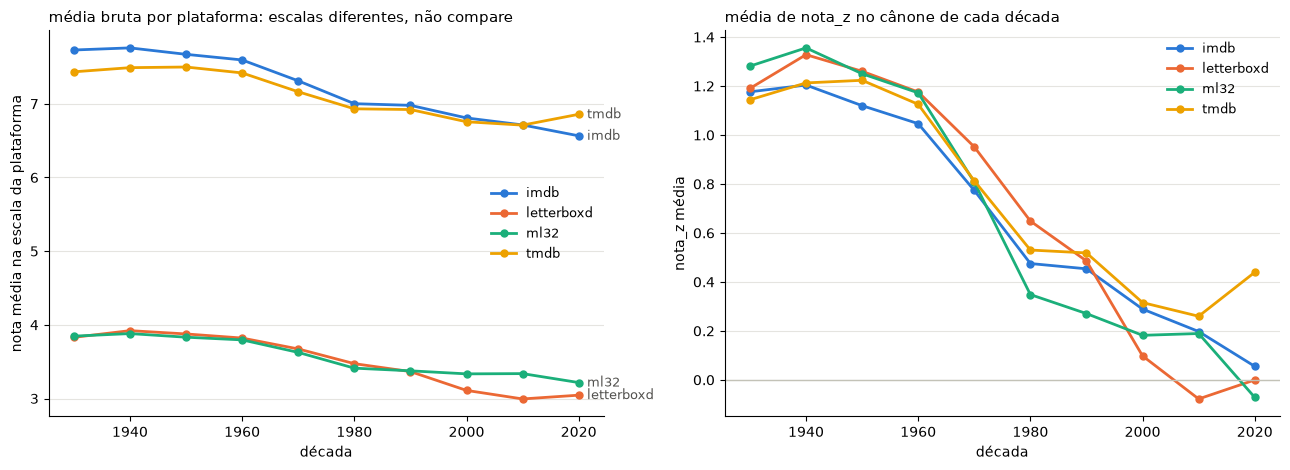

In [7]:
serie = con.sql("""
select d.decada, n.plataforma, avg(n.nota) as media_bruta, avg(n.nota_z) as media_z
from notas_normalizadas n join dim_titulo d using (tconst)
where d.pct_votos_decada >= 0.75
group by 1, 2 order by 1, 2
""").df()

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
paineis = (
    (eixos[0], "media_bruta", "média bruta por plataforma: escalas diferentes, não compare"),
    (eixos[1], "media_z", "média de nota_z no cânone de cada década"),
)
for eixo, coluna, titulo in paineis:
    for plataforma, cor in CORES.items():
        s = serie[serie.plataforma == plataforma]
        eixo.plot(s.decada, s[coluna], color=cor, linewidth=2, marker="o", markersize=5, label=plataforma)
        if coluna == "media_bruta":  # rótulo direto só onde as linhas não se cruzam na ponta
            eixo.annotate(plataforma, (s.decada.iloc[-1], s[coluna].iloc[-1]), xytext=(6, 0),
                          textcoords="offset points", va="center", fontsize=9, color=CINZA)
    eixo.set_title(titulo, fontsize=11, loc="left")
    eixo.set_xlabel("década")
    eixo.legend(frameon=False, fontsize=9)
    estilo(eixo, zero=(coluna == "media_z"))
eixos[0].set_ylabel("nota média na escala da plataforma")
eixos[1].set_ylabel("nota_z média")
plt.tight_layout()
plt.show()

À esquerda as quatro linhas nem cabem no mesmo eixo. À direita, com a posição dentro da plataforma e a
população controlada, aparece a coisa que a tese procura: as três plataformas grandes andam juntas e o
Letterboxd descola, pra cima nas décadas do meio e pra baixo nas recentes. O resto da seção mede isso.


### 6.1 o gap IMDb x Letterboxd por década, dentro de quartil de visibilidade

`gap_z` do par `imdb_letterboxd` (positivo = Letterboxd avalia melhor), média por década e quartil de
`pct_votos_decada`. Célula com menos de 30 filmes fica de fora.


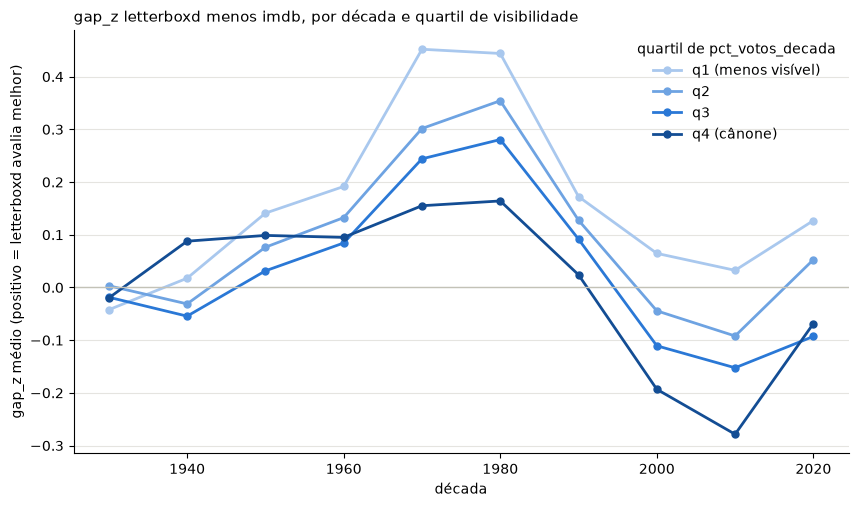

quartil,q1 (menos visível),q2,q3,q4 (cânone)
decada,,,,
1930,-0.04,0.00,-0.02,-0.02
1940,0.02,-0.03,-0.05,0.09
1950,0.14,0.08,0.03,0.10
1960,0.19,0.13,0.08,0.10
1970,0.45,0.30,0.24,0.16
1980,0.44,0.35,0.28,0.16
1990,0.17,0.13,0.09,0.02
2000,0.06,-0.04,-0.11,-0.19
2010,0.03,-0.09,-0.15,-0.28


In [8]:
celulas = lb.groupby(["decada", "quartil"]).gap_z.agg(gap="mean", n="size").reset_index()
celulas = celulas[celulas.n >= 30]

fig, ax = plt.subplots(figsize=(10, 5.5))
for q in QUARTIS:
    s = celulas[celulas.quartil == q]
    ax.plot(s.decada, s.gap, color=CORES_QUARTIL[q], linewidth=2, marker="o", markersize=5, label=q)
ax.set_title("gap_z letterboxd menos imdb, por década e quartil de visibilidade", fontsize=11, loc="left")
ax.set_xlabel("década")
ax.set_ylabel("gap_z médio (positivo = letterboxd avalia melhor)")
ax.legend(title="quartil de pct_votos_decada", frameon=False)
estilo(ax, zero=True)
plt.show()
celulas.pivot(index="decada", columns="quartil", values="gap").round(2)

**Leitura.** Antes de 1960 as duas plataformas concordam em todo nível de visibilidade. De 1960 a 1990 o
Letterboxd avalia relativamente melhor, e quanto menos visível o filme, maior o gap: nos anos 1970-80 o
quartil menos visível está em +0,45 e o cânone em +0,16. A partir de 2000 o sinal vira e o gap é maior
justamente no cânone: o blockbuster dos anos 2000-2010 é onde a amostra do Letterboxd é mais dura (-0,19 e
-0,28), enquanto o filme pouco visível fica perto de zero.

Então o gap depende da década, mas o sinal depende do quartil. As duas pontas da história são o filme obscuro
dos anos 1970 (Letterboxd puxa pra cima) e o sucesso recente (Letterboxd puxa pra baixo). Não é "o Letterboxd
gosta de clássico": o cânone antigo (1930-1950) está em zero pra todo mundo.


### 6.2 qual par de plataformas mais discorda

Desvio-padrão do `gap_z` por par, no frame inteiro, e a correlação entre os z do par. Depois, o mesmo
desvio por década, **só no cânone**: comparar décadas no frame inteiro mistura a composição (as décadas
recentes têm mais não-cânone) com a discordância de verdade.


,par,n,dp_gap_z,corr_z
0,letterboxd_tmdb,16329,0.695,0.758
1,letterboxd_ml32,14002,0.625,0.805
2,ml32_tmdb,14261,0.556,0.845
3,imdb_letterboxd,16377,0.550,0.849
4,imdb_tmdb,17399,0.451,0.898
5,imdb_ml32,14262,0.387,0.925


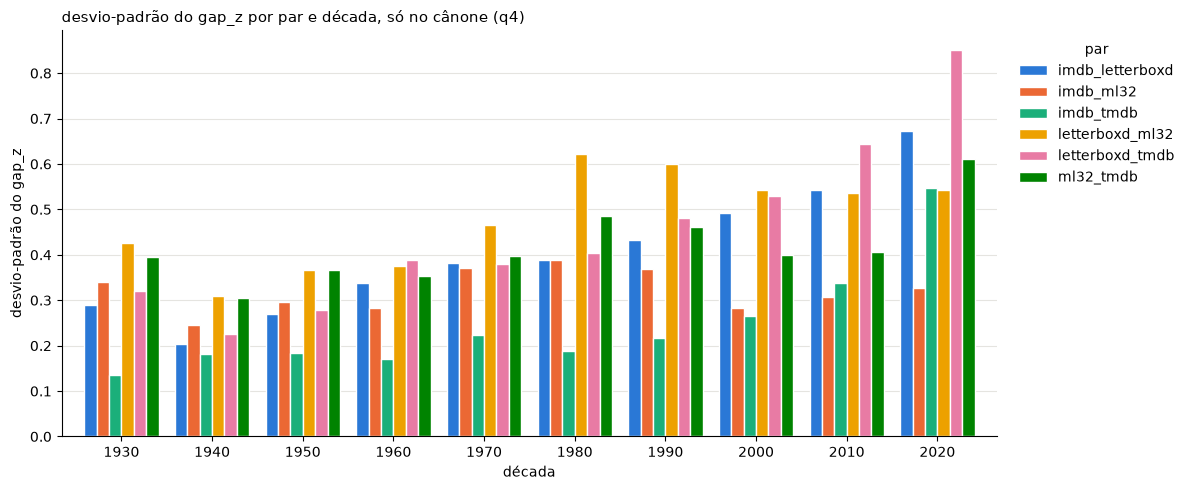

In [9]:
display(con.sql("""
select plataforma_a || '_' || plataforma_b as par, count(*) as n,
  round(stddev(gap_z), 3) as dp_gap_z, round(corr(z_a, z_b), 3) as corr_z
from divergencia_par group by 1 order by 3 desc
""").df())

canone = par[par.quartil == QUARTIS[3]].groupby(["par", "decada"]).gap_z.agg(dp="std", n="size").reset_index()
canone = canone[canone.n >= 30].pivot(index="decada", columns="par", values="dp")

fig, ax = plt.subplots(figsize=(12, 5))
canone.plot.bar(ax=ax, color=CORES_PAR, width=0.82, edgecolor="white", linewidth=1, rot=0)
ax.set_title("desvio-padrão do gap_z por par e década, só no cânone (q4)", fontsize=11, loc="left")
ax.set_xlabel("década")
ax.set_ylabel("desvio-padrão do gap_z")
ax.legend(title="par", frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
estilo(ax)
plt.tight_layout()
plt.show()

**Leitura.** O par que mais discorda é Letterboxd x TMDB (desvio 0,70, correlação 0,76), depois Letterboxd x
ml-32m; o que mais concorda é IMDb x ml-32m (0,93). O padrão é mais limpo que "público geral contra
cinéfilo": todo par com Letterboxd discorda mais, todo par com IMDb concorda mais. A plataforma que descola é
o Letterboxd, seja com quem for.

Dentro do cânone, IMDb x ml-32m fica plano de 1990 em diante, então o crescimento dele com a década era
composição do frame. Os pares com Letterboxd ou TMDB continuam crescendo mesmo dentro do quartil, e essa
parte é real: o cânone recente é onde o Letterboxd mais diverge, que é o que 6.1 mostrou por outro ângulo.


### 6.3 país de produção, controlando década e visibilidade

`gap_z` do par IMDb x Letterboxd por país, com o controle mais simples que existe: de cada filme se subtrai a
média da sua célula década x quartil, e o que sobra se agrega por `pais_unico`. Coprodução entra como
categoria própria, separada em com e sem os EUA. Só grupos com 100+ filmes; a barra é o intervalo de 95%.


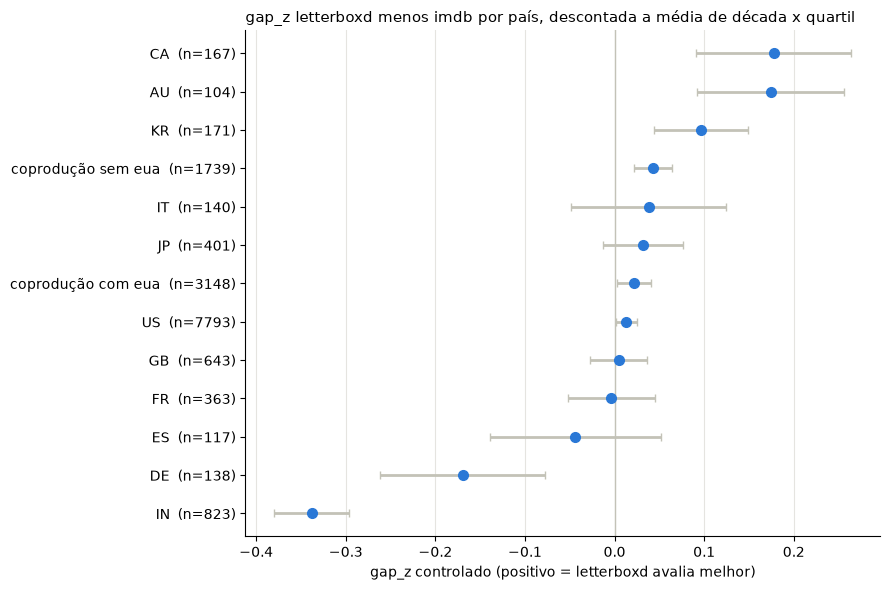

,n,gap,dp,ic95
origem,,,,
IN,823,-0.34,0.61,0.04
DE,138,-0.17,0.55,0.09
ES,117,-0.04,0.53,0.10
FR,363,-0.00,0.47,0.05
GB,643,0.00,0.42,0.03
US,7793,0.01,0.52,0.01
coprodução com eua,3148,0.02,0.54,0.02
JP,401,0.03,0.45,0.04
IT,140,0.04,0.52,0.09


In [10]:
lb["origem"] = np.select(
    [(lb.n_paises > 1) & lb.tem_us, lb.n_paises > 1],
    ["coprodução com eua", "coprodução sem eua"],
    default=lb.pais_unico.to_numpy(),
)
pais = (lb.groupby("origem").gap_ctrl.agg(n="size", gap="mean", dp="std")
        .query("n >= 100").sort_values("gap"))
pais["ic95"] = 1.96 * pais.dp / np.sqrt(pais.n)

fig, ax = plt.subplots(figsize=(9, 6))
posicao = np.arange(len(pais))
ax.errorbar(pais.gap, posicao, xerr=pais.ic95, fmt="o", color=CORES["imdb"], ecolor=ZERO, elinewidth=2, capsize=3, markersize=7)
ax.axvline(0, color=ZERO, linewidth=1)
ax.set_yticks(posicao, [f"{origem}  (n={n})" for origem, n in zip(pais.index, pais.n)])
ax.set_title("gap_z letterboxd menos imdb por país, descontada a média de década x quartil", fontsize=11, loc="left")
ax.set_xlabel("gap_z controlado (positivo = letterboxd avalia melhor)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color=GRADE, linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
pais.round(2)

**Leitura.** Os EUA ficam perto de zero (são a maior parte de toda célula), e o interessante é a dispersão
em volta. Canadá (+0,18) e Austrália (+0,17) são onde o Letterboxd é mais generoso em relação ao IMDb, Coreia
(+0,10) em seguida; Reino Unido, França, Japão e os dois tipos de coprodução ficam a menos de 0,05 dos EUA.
Do outro lado, Alemanha (-0,17) e, muito fora, **Índia (-0,34, n = 823)**: a amostra do Letterboxd avalia o
cinema indiano bem abaixo de onde o IMDb o coloca, e isso sobrevive ao controle de década e quartil.

O efeito de origem existe, mas é de países específicos, não "Hollywood contra o mundo"; coprodução com os
EUA se comporta como os EUA. E vale a regra 2: isso é a amostra de 11 mil usuários pesados do Letterboxd
contra a base do IMDb, que tem público indiano grande.


### 6.4 divergência de visibilidade

Votos no IMDb contra votos no Letterboxd, em log-log, e a razão `votos_letterboxd / votos_imdb` (por mil
votos do IMDb) por década e quartil, e por país. Aqui não entra filtro de volume: o filme com cinco notas no
Letterboxd, ou nenhuma, é o objeto da pergunta.


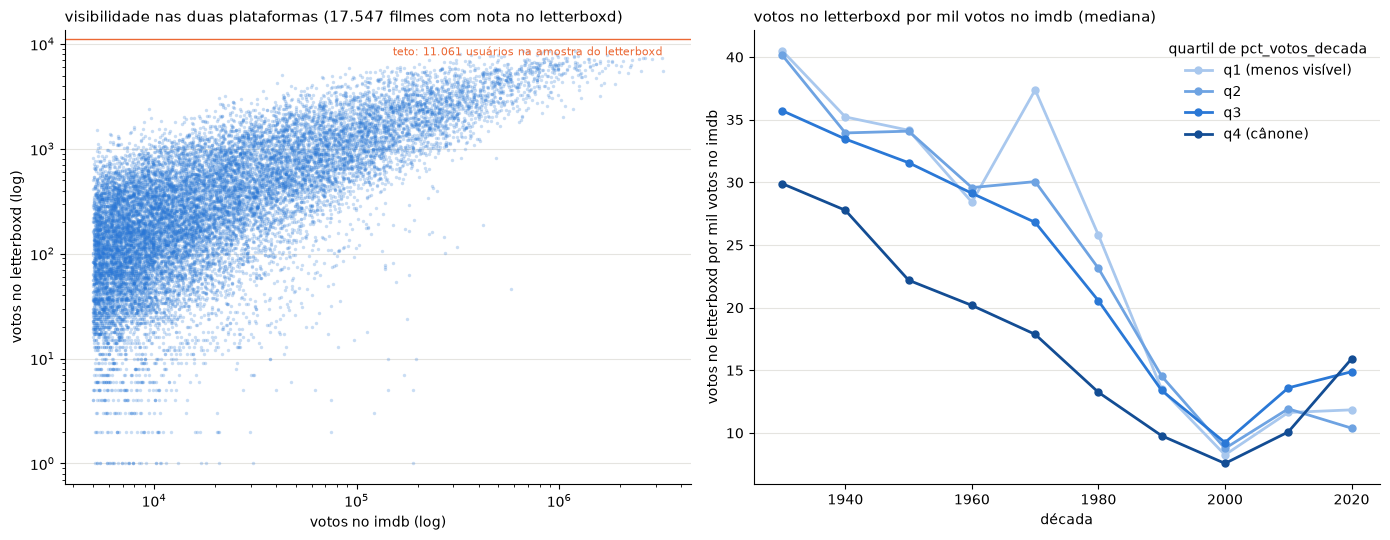

,n,mediana
origem,,
JP,412,24.8
IT,163,19.4
GB,670,18.7
US,7984,15.7
KR,174,15.4
CA,179,15.0
AU,114,14.4
coprodução,5095,12.7
FR,400,12.6


In [11]:
votos = con.sql("""
select d.tconst, d.decada, d.pct_votos_decada, d.n_paises, d.pais_unico,
  i.n_votos as votos_imdb, coalesce(l.n_votos, 0) as votos_lb
from dim_titulo d
join fato_notas i on i.tconst = d.tconst and i.plataforma = 'imdb'
left join fato_notas l on l.tconst = d.tconst and l.plataforma = 'letterboxd'
""").df()
votos["razao"] = votos.votos_lb / votos.votos_imdb * 1000
votos["quartil"] = quartil(votos.pct_votos_decada)
com_lb = votos[votos.votos_lb > 0]

fig, eixos = plt.subplots(1, 2, figsize=(14, 5.5))
eixos[0].scatter(com_lb.votos_imdb, com_lb.votos_lb, s=6, alpha=0.25, color=CORES["imdb"], linewidths=0)
eixos[0].set(xscale="log", yscale="log")
eixos[0].axhline(11061, color=CORES["letterboxd"], linewidth=1)
eixos[0].annotate("teto: 11.061 usuários na amostra do letterboxd", (com_lb.votos_imdb.max(), 11061),
                  xytext=(0, -5), textcoords="offset points", ha="right", va="top", fontsize=8, color=CORES["letterboxd"])
eixos[0].set_title(f"visibilidade nas duas plataformas ({len(com_lb):,} filmes com nota no letterboxd)".replace(",", "."), fontsize=11, loc="left")
eixos[0].set_xlabel("votos no imdb (log)")
eixos[0].set_ylabel("votos no letterboxd (log)")
estilo(eixos[0])

razao = votos.groupby(["decada", "quartil"]).razao.median().reset_index()
for q in QUARTIS:
    s = razao[razao.quartil == q]
    eixos[1].plot(s.decada, s.razao, color=CORES_QUARTIL[q], linewidth=2, marker="o", markersize=5, label=q)
eixos[1].set_title("votos no letterboxd por mil votos no imdb (mediana)", fontsize=11, loc="left")
eixos[1].set_xlabel("década")
eixos[1].set_ylabel("votos no letterboxd por mil votos no imdb")
eixos[1].legend(title="quartil de pct_votos_decada", frameon=False)
estilo(eixos[1])
plt.tight_layout()
plt.show()

votos["origem"] = np.where(votos.n_paises > 1, "coprodução", votos.pais_unico)
(votos.groupby("origem").razao.agg(n="size", mediana="median")
 .query("n >= 100").sort_values("mediana", ascending=False).round(1))

**Leitura.** Em log-log as duas plataformas são uma banda só com uma cauda comprida embaixo: a correlação dos
logs fica entre 0,6 e 0,85 em toda década, então a visibilidade anda junta, e a cauda (milhares de votos no
IMDb, um punhado no Letterboxd) é onde mora a pergunta. O que tem perfil é a razão. Por década: um filme dos
anos 1930 recebe 30-40 votos no Letterboxd por mil do IMDb, um dos anos 2000 recebe ~8, e volta pra 10-16
nos anos 2010-2020. Dentro da década, o filme menos visível recebe proporcionalmente mais atenção do
Letterboxd que o cânone (anos 1970: 37 contra 18), que é a história da canonicidade vista pelo lado dos
votos. E por país é brutal: Japão 25, Itália 19, Reino Unido 19, EUA 16 ... Índia 3, Turquia 1. O filme
"enorme no IMDb, ausente no Letterboxd" é o indiano e o turco, o mesmo perfil que 6.3 achou nas notas.


### 6.5 duração

Pergunta que surgiu na exploração: o gap IMDb x Letterboxd muda com a duração do filme? Curto (< 90 min),
médio (90-120) e longo (> 120), bruto e com o mesmo controle de década x quartil de 6.3.


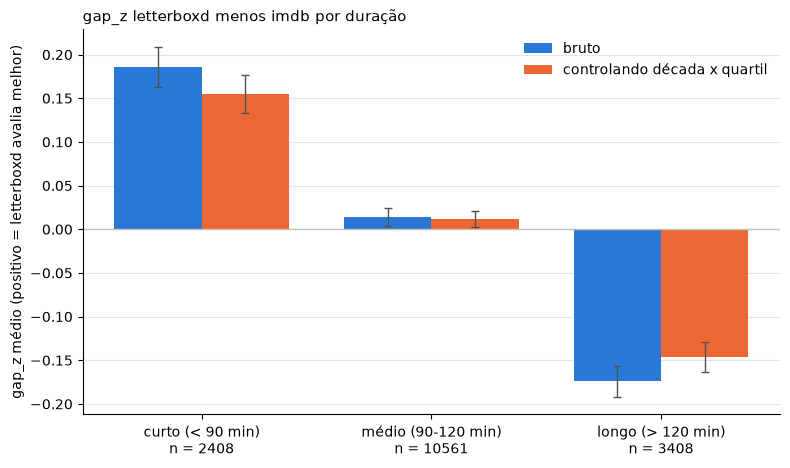

,n,bruto,ctrl
duracao_cat,,,
curto (< 90 min),2408,0.19,0.16
médio (90-120 min),10561,0.01,0.01
longo (> 120 min),3408,-0.17,-0.15


In [12]:
DURACOES = ["curto (< 90 min)", "médio (90-120 min)", "longo (> 120 min)"]
lb["duracao_cat"] = pd.cut(lb.duracao, [0, 89, 120, 10_000], labels=DURACOES)
resumo = (lb.groupby("duracao_cat", observed=True)
          .agg(n=("gap_z", "size"), bruto=("gap_z", "mean"), bruto_dp=("gap_z", "std"),
               ctrl=("gap_ctrl", "mean"), ctrl_dp=("gap_ctrl", "std"))
          .reindex(DURACOES))

x = np.arange(len(DURACOES))
larg = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
for desloc, coluna, rotulo, cor in ((-larg / 2, "bruto", "bruto", CORES["imdb"]),
                                    (larg / 2, "ctrl", "controlando década x quartil", CORES["letterboxd"])):
    ic = 1.96 * resumo[f"{coluna}_dp"] / np.sqrt(resumo.n)
    ax.bar(x + desloc, resumo[coluna], larg, yerr=ic, color=cor, label=rotulo,
           error_kw={"ecolor": CINZA, "capsize": 3, "linewidth": 1})
ax.set_xticks(x, [f"{d}\nn = {n}" for d, n in zip(DURACOES, resumo.n)])
ax.set_title("gap_z letterboxd menos imdb por duração", fontsize=11, loc="left")
ax.set_ylabel("gap_z médio (positivo = letterboxd avalia melhor)")
ax.legend(frameon=False)
estilo(ax, zero=True)
plt.show()
resumo[["n", "bruto", "ctrl"]].round(2)

**Leitura.** Filme curto é território do Letterboxd (+0,19), filme longo é território do IMDb (-0,17), e o
meio é plano. Não é década nem visibilidade disfarçada: descontada a média da célula, os números quase não
se mexem (+0,16 / +0,01 / -0,15). A ressalva é que duração e gênero andam juntos (o filme de 80 minutos e o
de 150 não são o mesmo tipo de filme), e gênero é o próximo controle a testar.


### 6.6 deriva: a nota muda com a distância do lançamento?

`deriva_ml32`: pra cada filme e ano de avaliação no ml-32m, o desvio da nota daquele ano contra a média do
próprio filme. Pra não trocar os filmes no meio da curva, o painel fica só com títulos observados em todos
os anos de 0 a 10 depois do lançamento, sempre com 30+ notas no filme-ano. Cânone e não-cânone são
separados, mas dentro de cada linha são exatamente os mesmos títulos do começo ao fim.


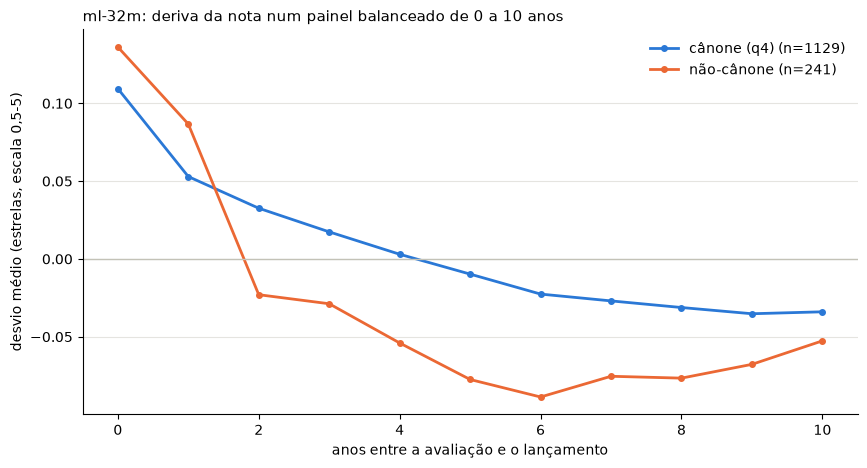

n_filmes                 desvio           
grupo     cânone (q4) não-cânone cânone (q4) não-cânone
distancia                                              
0              1129.0      241.0       0.109      0.136
10             1129.0      241.0      -0.034     -0.053

In [13]:
deriva = con.sql("""
with base as (
  select m.tconst, m.ano_avaliacao - d.ano as distancia, m.desvio_do_ano,
    case when d.pct_votos_decada >= 0.75 then 'cânone (q4)' else 'não-cânone' end as grupo
  from deriva_ml32 m join dim_titulo d using (tconst)
  where m.n_notas >= 30 and m.ano_avaliacao - d.ano between 0 and 10
),
balanceados as (
  select tconst, grupo from base group by 1, 2 having count(distinct distancia) = 11
)
select b.distancia, b.grupo, count(distinct b.tconst) as n_filmes, avg(b.desvio_do_ano) as desvio
from base b join balanceados p using (tconst, grupo)
group by 1, 2 order by 1, 2
""").df()

fig, ax = plt.subplots(figsize=(10, 5))
for grupo, cor in (("cânone (q4)", CORES["imdb"]), ("não-cânone", CORES["letterboxd"])):
    s = deriva[deriva.grupo == grupo]
    rotulo = f"{grupo} (n={int(s.n_filmes.iloc[0])})"
    ax.plot(s.distancia, s.desvio, color=cor, linewidth=2, marker="o", markersize=4, label=rotulo)
ax.set_title("ml-32m: deriva da nota num painel balanceado de 0 a 10 anos", fontsize=11, loc="left")
ax.set_xlabel("anos entre a avaliação e o lançamento")
ax.set_ylabel("desvio médio (estrelas, escala 0,5-5)")
ax.legend(frameon=False)
estilo(ax, zero=True)
plt.show()
deriva[deriva.distancia.isin([0, 10])].pivot(index="distancia", columns="grupo", values=["n_filmes", "desvio"]).round(3)

**Leitura.** Agora a comparação acompanha os mesmos 1.370 filmes em todos os pontos. No cânone a nota sai
de +0,11 no ano do lançamento pra -0,03 no décimo ano; fora dele, de +0,14 pra -0,05, com um fundo ainda
mais baixo por volta do sexto ano. A queda é de 0,14 a 0,19 estrela numa escala de cinco. O desenho fica
mais limpo sem a troca de títulos, mas não acompanha as mesmas pessoas: mostra que o mesmo conjunto de
filmes recebe notas mais altas perto do lançamento, não que cada usuário fica mais rigoroso com o tempo.


### 6.7 faixa etária, por gênero

No agregado (`gradiente_idade`), a média bruta do ml-1m sobe com a idade (3,56 -> 3,78), mas o desvio dentro
do filme fica entre -0,02 e +0,07: cada faixa avaliou um catálogo diferente, não o mesmo filme de forma
diferente. A pergunta é se o gradiente reaparece dentro de gênero. Como a lista do IMDb é alfabética e não
tem gênero principal, cada filme entra em todos os seus gêneros. Pra reduzir célula ruidosa, entram só
filme-faixas com 10+ notas e gêneros com 50+ filmes em todas as faixas.


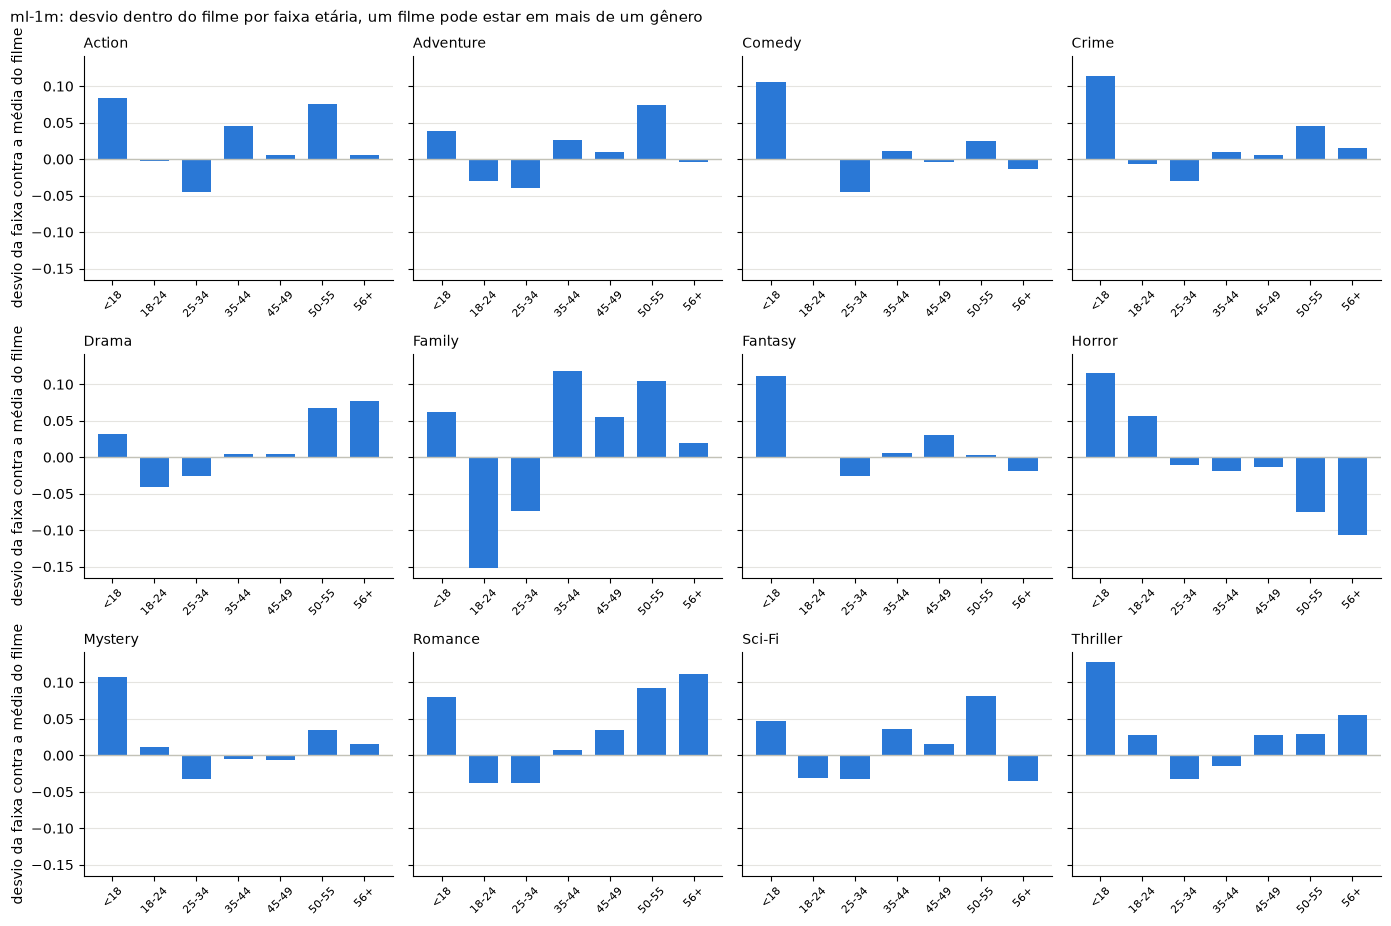

faixa_etaria,<18,18-24,25-34,35-44,45-49,50-55,56+
genero,,,,,,,
Action,193,408,455,433,352,318,209
Adventure,248,422,447,429,371,343,238
Comedy,405,921,1025,934,686,607,398
Crime,153,409,502,444,331,300,216
Drama,380,1134,1437,1321,1051,984,722
Family,104,170,178,164,125,112,58
Fantasy,79,178,199,190,148,132,74
Horror,76,231,285,265,184,156,61
Mystery,71,176,217,207,166,153,112


In [14]:
MIN_NOTAS_FILME_FAIXA = 10
MIN_FILMES_GENERO_FAIXA = 50
idade = con.sql(f"""
select trim(g.genero) as genero, n.faixa_etaria, n.faixa_etaria_cod,
  count(distinct n.tconst) as n_filmes, sum(n.n_notas) as n_notas, avg(n.desvio_no_filme) as desvio
from notas_por_faixa_etaria n
join dim_titulo d using (tconst), unnest(string_split(d.generos, ',')) as g(genero)
where n.n_notas >= {MIN_NOTAS_FILME_FAIXA}
group by 1, 2, 3 order by 1, 3
""").df()
minimo = idade.groupby("genero").n_filmes.min()
idade = idade[idade.genero.isin(minimo[minimo >= MIN_FILMES_GENERO_FAIXA].index)]
faixas = idade.sort_values("faixa_etaria_cod").faixa_etaria.unique()
generos = sorted(idade.genero.unique())

n_colunas = 4
n_linhas = int(np.ceil(len(generos) / n_colunas))
fig, eixos = plt.subplots(n_linhas, n_colunas, figsize=(14, 2.8 * n_linhas + 1), sharey=True)
eixos = np.atleast_1d(eixos).ravel()
for eixo, genero in zip(eixos.flat, generos):
    s = idade[idade.genero == genero].set_index("faixa_etaria").reindex(faixas)
    eixo.bar(faixas, s.desvio, color=CORES["imdb"], width=0.7)
    eixo.set_title(genero, fontsize=10, loc="left")
    eixo.tick_params(axis="x", labelrotation=45, labelsize=8)
    estilo(eixo, zero=True)
for eixo in eixos.flat[len(generos):]:
    eixo.set_visible(False)
for linha in range(n_linhas):
    eixos[linha * n_colunas].set_ylabel("desvio da faixa contra a média do filme")
fig.suptitle("ml-1m: desvio dentro do filme por faixa etária, um filme pode estar em mais de um gênero", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()
idade.pivot(index="genero", columns="faixa_etaria", values="n_filmes")[faixas].astype(int)

**Leitura.** Com todos os gêneros do filme e um piso de notas, o contraste principal continua. Em Drama o
desvio vai de -0,04 em 18-24 pra +0,08 em 56+; em Horror faz o caminho contrário, de +0,06 em 18-24 pra
-0,11 em 56+. Os outros gêneros oscilam sem formar um gradiente simples. Então "a idade muda a nota" ainda
é amplo demais: a associação depende do gênero, e cada filme pode contribuir pra mais de um painel.


## 7. síntese

- **A tese se sustenta, e com direção.** IMDb, TMDB e ml-32m concordam entre si
  (correlação de z 0,85-0,93); o Letterboxd é a que descola (0,76-0,85), seja com quem for pareado.
- **O descolamento tem década e tem visibilidade.** A amostra do Letterboxd puxa pra cima o filme pouco
  visível dos anos 1960-80 (+0,45 de gap no quartil inferior) e puxa pra baixo o cânone dos anos 2000-2010
  (-0,28). Não é "gosta de clássico": o cânone antigo está em zero.
- **Tem país, e é país específico.** Canadá e Austrália pra cima, Índia muito pra baixo (-0,34 com o controle
  de década e quartil). Coprodução com os EUA se comporta como os EUA.
- **A visibilidade tem o mesmo perfil.** Por mil votos no IMDb, um filme japonês recebe 25 no Letterboxd,
  um americano 16, um indiano 3, um turco 1. Cobertura baixa é canonicidade, não dado faltante.
- **Dentro do filme, o tempo e a idade mexem pouco mas mexem.** No painel balanceado, a nota cai de 0,14 a
  0,19 estrela entre o lançamento e dez anos depois; a associação com idade depende do gênero (drama sobe,
  horror cai).
- **Dois achados de engenharia viraram resultado:** a cobertura do Letterboxd é canonicidade (regra 4) e o
  gradiente de idade do agregado era composição da cesta (regra 7).


## 8. próximos passos

Da E1: `classificacao_br` (40% do frame, enviesada pra recente) ainda não foi testada contra o `gap_z`
controlando década; a discordância por par (6.2) foi aberta por década e falta abrir por gênero e país; e o
achado de duração (6.5) precisa do controle de gênero antes de ser afirmado.

Da E2: o mesmo pacote alimenta o dashboard, a redução de dimensionalidade e agrupamento dos filmes pelo
vetor de z das quatro plataformas, e os modelos de regressão e classificação do `gap_z` a partir de década,
país, gênero, duração e classificação.

**Extra: adição de novas plataformas na análise. Se limitar a concordar que IMDb, TMDB e ml-32m acaba sendo prolixo, visto que a tese só se autoembasa quando os dados do Letterboxd entram: dessa forma, com dados mais específicos/diferentes, a proposta seria ainda mais nutrida**

## 9. fontes, ferramentas e atribuição

**Dados**

- IMDb. *Non-Commercial Datasets*. https://developer.imdb.com/non-commercial-datasets/ - coletado em
  13/09/2026, uso pessoal e não comercial.
- The Movie Database (TMDB) API. https://www.themoviedb.org/ - coletado em 13/09/2026. *This product uses the
  TMDB API but is not endorsed or certified by TMDB.*
- Harper, F. M., & Konstan, J. A. (2015). The MovieLens Datasets: History and Context. *ACM Transactions on
  Interactive Intelligent Systems*, 5(4), Article 19. https://doi.org/10.1145/2827872 - ml-32m (gerado em
  13/10/2023) e ml-1m (2003), https://grouplens.org/datasets/movielens/.
- freeth. *Letterboxd film ratings* [dataset]. Kaggle, CC0-1.0.
  https://www.kaggle.com/datasets/freeth/letterboxd-film-ratings - dump de 10/10/2023.
- Wikidata contributors. Propriedades P6127 (Letterboxd film ID), P345 (IMDb ID) e P4947 (TMDB film ID),
  CC0. https://www.wikidata.org/ - extraído em 13/09/2026 via Wikidata Query Service.

**APIs e serviços**

- TMDB API v3 (`/find`, `/movie/{id}` com `external_ids`, `release_dates`, `credits`, `keywords`), com
  chave registrada pelo grupo.
- Wikidata Query Service (SPARQL), consulta em `ops/wikidata.sparql`.
- Kaggle (download do dataset do Letterboxd via `kaggle` CLI), GitHub (repositório), Google Drive e Colab
  (distribuição do pacote e execução dos cadernos).

**Bibliotecas** (versões em `ops/requirements.txt`)

- DuckDB: todo o pipeline em SQL sobre parquet, e as consultas deste caderno.
- pandas, NumPy e PyArrow: manipulação dos dataframes e leitura/escrita de parquet.
- Matplotlib: gráficos.
- requests e python-dotenv: crawler do TMDB.
- jupytext e Jupyter: cadernos.

**Repositório:** https://github.com/joseduardop/quem-avalia-o-que - pipeline (`etl/`), ferramentas (`ops/`),
relatórios de cada etapa (`recon/relatorio.md`, `docs/ponte-wikidata.md`, `docs/confundimento-tmdb.md`,
`docs/fato-notas.md`), dicionário do pacote (`docs/README-tabelao.md`) e os cadernos `00` a `03`.
